# Lab 2: Data Visualization and InterpretationUsing Matplotlib-I

## Imports

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

## Loading data

In [2]:
df = pd.read_csv("datasets/House_Rent_Dataset.csv")
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


## 1. Line plot

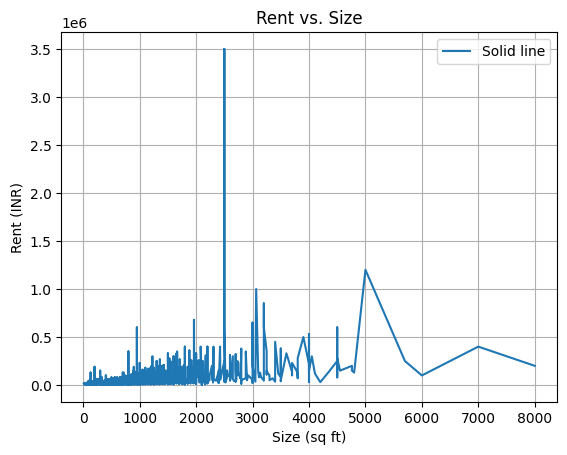

In [3]:
df_s = df.sort_values(by="Size")

plt.plot(df_s["Size"], df_s["Rent"], linestyle='solid', label="Solid line")
plt.title("Rent vs. Size")
plt.xlabel("Size (sq ft)")
plt.ylabel("Rent (INR)")
plt.grid(True)
plt.legend(loc="upper right")
plt.savefig("plots/line_plot.png")
plt.show()

This line plot illustrates the relationship between the size of a flat and its rent. Different line styles are used to improve visual clarity, showing how rent generally increases with flat size.

## 2. Line plot

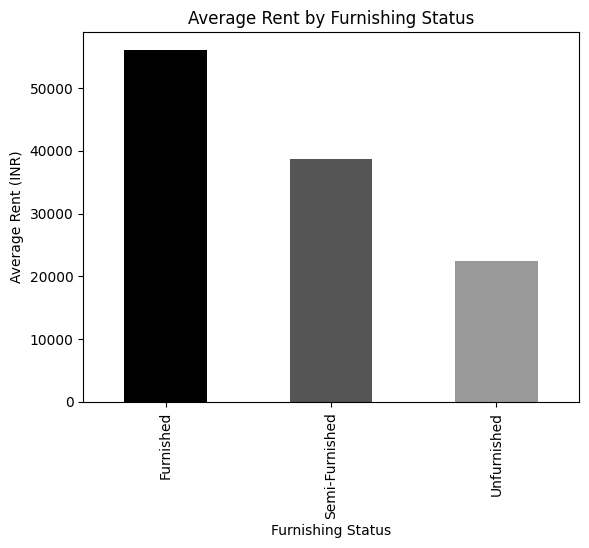

In [4]:
avg_rent = df.groupby("Furnishing Status")["Rent"].mean()

avg_rent.plot(kind="bar", color=["#000", "#555", "#999"])
plt.title("Average Rent by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Average Rent (INR)")
plt.savefig("plots/lab2/bar_chart.png")
plt.show()

The bar chart is of Furnishing Status vs avg Rent. From this plot we can see that Furnished houses have high rent.

## 3. Scatter plot

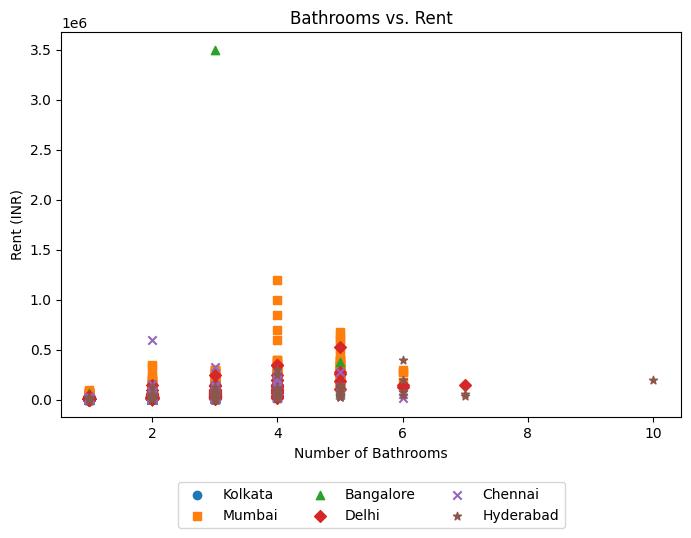

In [5]:
plt.figure(figsize=(8,5))

cities = df["City"].unique()
markers = ['o', 's', '^', 'D', 'x', '*']

for city, marker in zip(cities, markers):
    city_data = df[df["City"] == city]
    plt.scatter(city_data["Bathroom"], city_data["Rent"], marker=marker, label=city)

plt.title("Bathrooms vs. Rent")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Rent (INR)")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.savefig("plots/lab2/scatter_plot.png")
plt.show()

This plot is of number of bathrooms vs. rent with different markers showing different cities. From this plot we can see that there is one house in hyderabad with 10 bathrooms with about 3 lackhs of rent and also has a house in banglor with 35 lackhs.

## 4. Histogram

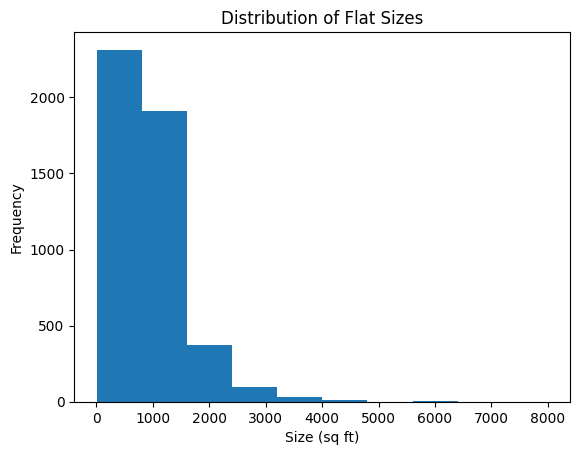

In [6]:
plt.hist(df["Size"], bins=10)
plt.title("Distribution of Flat Sizes")
plt.xlabel("Size (sq ft)")
plt.ylabel("Frequency")
plt.savefig("plots/lab2/histogram.png")
plt.show()

This is Histogram of size of houses. we can see that median size is about 900 sq ft.

## 5. Stacked Bar Chart

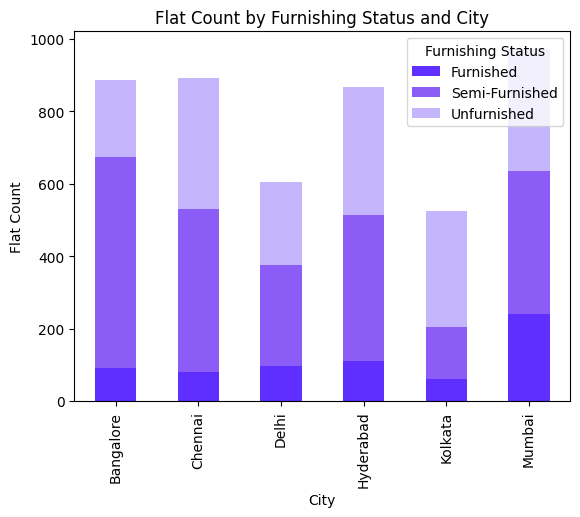

In [7]:
city_furnish = pd.crosstab(df["City"], df["Furnishing Status"])

city_furnish.plot(
    kind="bar", stacked=True,
    color=["#5F2FFF", "#8B5CF6", "#C4B5FD"]
)
plt.title("Flat Count by Furnishing Status and City")
plt.xlabel("City")
plt.ylabel("Flat Count")

plt.savefig("plots/lab2/stacked_bar.png")
plt.show()

This is stacked bar chart it represents the number of flats in each city by their furnishing status. it helps in comparing which cities have more or less furnished houses and also see that how many houses are furnished in the city.

## 6.  Pie Chart

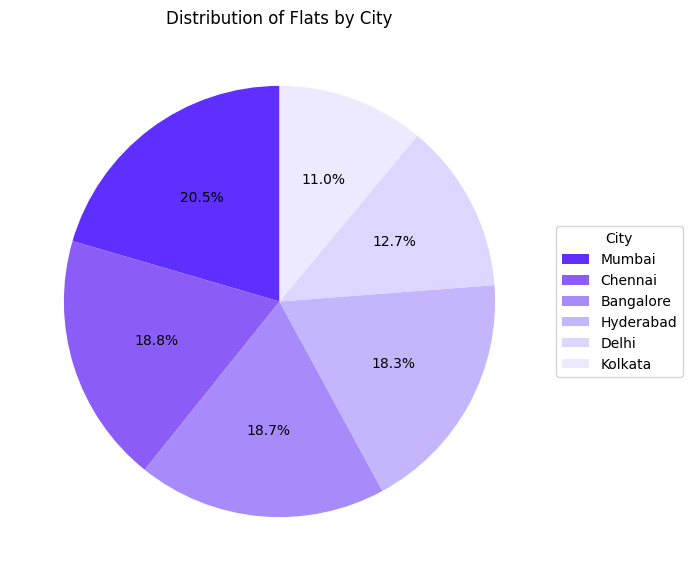

In [8]:
city_counts = df["City"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(7,7))

plt.pie(
    city_counts,
    autopct='%1.1f%%',
    startangle=90,
    colors=["#5F2FFF", "#8B5CF6", "#A78BFA", "#C4B5FD", "#DDD6FE", "#EDE9FE"]
)

plt.title("Distribution of Flats by City")

# Add legend mapping colors to cities
plt.legend(
    city_counts.index,
    title="City",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.savefig("plots/lab2/pie_chart.png", bbox_inches="tight")
plt.show()


This is pie chart it shows the percentage of flats in different cities. and we can see that mumbai chennai banglor and hyderabad have the same amount of flats.

## 7. Stacked Plot

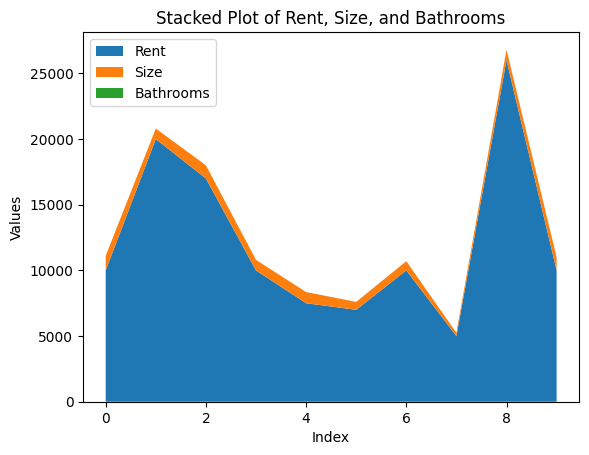

In [9]:
sample = df.head(10)

plt.stackplot(
    sample.index,
    sample["Rent"], sample["Size"], sample["Bathroom"],
    labels=["Rent", "Size", "Bathrooms"]
)
plt.title("Stacked Plot of Rent, Size, and Bathrooms")
plt.xlabel("Index")
plt.ylabel("Values")
plt.legend(loc="upper left")
plt.savefig("plots/lab2/stacked_plot.png")
plt.show()

This stacked plot visualizes rent, size, and number of bathrooms for the first ten records in the dataset, showing their combined variation.